# Tarefa 2 — Descritores Float vs. Binários: Comparação Prática
**Atividade 3 · TECA2 20261 · Pontos de Interesse e seus Descritores**

**Alunos:** Henryque Oliveira, Matheus Marinho e Rodrigo Oliveira

Este notebook compara descritores **float** (SIFT) e **binários** (ORB, AKAZE) num par de imagens reais, avaliando quantidade de matches e o efeito do Ratio Test de Lowe.

### Base teórica

- **Descritores float** (SIFT, 128 floats): medem magnitudes contínuas de gradiente. A similaridade entre dois descritores é a **distância euclidiana** (`NORM_L2`): quanto menor, mais parecidos.
- **Descritores binários** (ORB, AKAZE): armazenam bits comparando pares de pixels. A similaridade é a **distância de Hamming** (`NORM_HAMMING`): conta quantos bits diferem — computacionalmente muito mais rápida.
- **Ratio Test de Lowe**: para cada keypoint encontramos os 2 melhores candidatos `(m, n)`. Aceitamos o match se `m.distance < ratio × n.distance`. Um ratio próximo de 1.0 indica ambiguidade — o match é descartado. Lowe mostrou empiricamente que `ratio = 0.75` elimina ~90% dos falsos matches preservando ~90% dos verdadeiros.

> Referências: Corke (2023) Seção 13.3 · Lowe (2004) Seção 7.1 · Slides TECA2 20261, slides 12–16.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('OpenCV:', cv2.__version__)
print('SIFT disponível:', hasattr(cv2, 'SIFT_create'))
print('AKAZE disponível:', hasattr(cv2, 'AKAZE_create'))

PATH_IMG1 = 'images/ursinho1.jpeg'
PATH_IMG2 = 'images/ursinho2.jpeg'

def load(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

OpenCV: 4.13.0
SIFT disponível: True
AKAZE disponível: True


## Item 1 — Par de imagens

Carregamos as duas fotos do ursinho tiradas com celular. O par deve ter sobreposição suficiente para gerar correspondências entre os descritores.

Imagem 1: 960×1280 px
Imagem 2: 960×1280 px


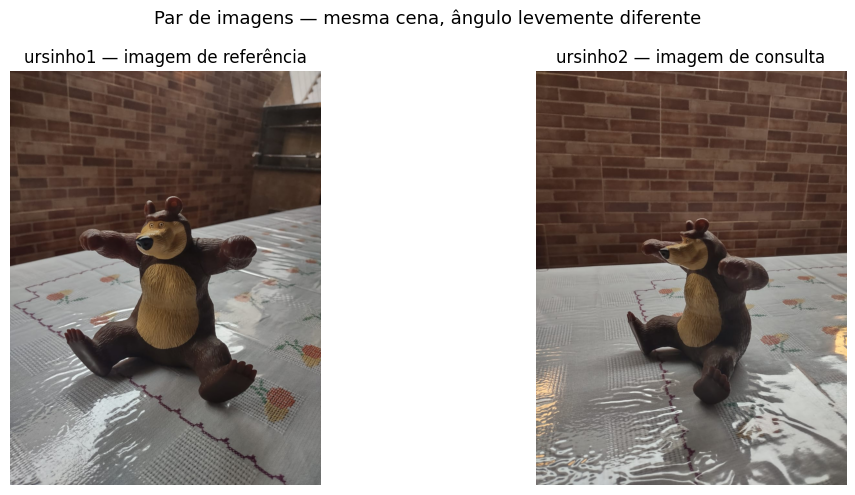

In [2]:
img1, gray1 = load(PATH_IMG1)
img2, gray2 = load(PATH_IMG2)

print(f'Imagem 1: {img1.shape[1]}×{img1.shape[0]} px')
print(f'Imagem 2: {img2.shape[1]}×{img2.shape[0]} px')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0].set_title('ursinho1 — imagem de referência')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[1].set_title('ursinho2 — imagem de consulta')
axes[1].axis('off')
plt.suptitle('Par de imagens — mesma cena, ângulo levemente diferente', fontsize=13)
plt.tight_layout()
plt.show()

## Item 2 — Pipeline de matching com cada descritor

Implementamos `pipeline_match()`: detecta keypoints, extrai descritores, aplica BFMatcher com a norma correta para cada tipo e filtra com o Ratio Test de Lowe. Rodamos para SIFT (`NORM_L2`), ORB (`NORM_HAMMING`) e AKAZE (`NORM_HAMMING`).

In [3]:
def pipeline_match(img1, img2, det_name='SIFT', ratio=0.75):
    g1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    if det_name == 'SIFT':
        det = cv2.SIFT_create()
        norm = cv2.NORM_L2
    elif det_name == 'ORB':
        det = cv2.ORB_create(nfeatures=2000)
        norm = cv2.NORM_HAMMING
    elif det_name == 'AKAZE':
        det = cv2.AKAZE_create()
        norm = cv2.NORM_HAMMING
    else:
        raise ValueError(f'det_name inválido: {det_name}')
    kp1, d1 = det.detectAndCompute(g1, None)
    kp2, d2 = det.detectAndCompute(g2, None)
    if d1 is None or d2 is None:
        print(f'{det_name}: descritores insuficientes')
        return kp1, kp2, []
    bf = cv2.BFMatcher(norm)
    pairs = bf.knnMatch(d1, d2, k=2)
    good = []
    for pair in pairs:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                good.append(m)
    n_ok  = len(good)
    n_tot = len(pairs)
    print(f'{det_name}: {len(kp1)} kp | {n_ok}/{n_tot} bons ({100*n_ok/n_tot:.1f}%)')
    return kp1, kp2, good

SIFT: 5535 kp | 97/5535 bons (1.8%)


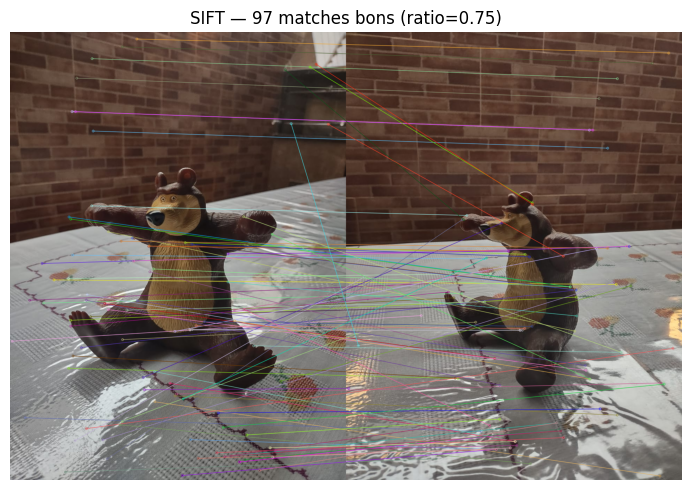

ORB: 2000 kp | 17/2000 bons (0.8%)


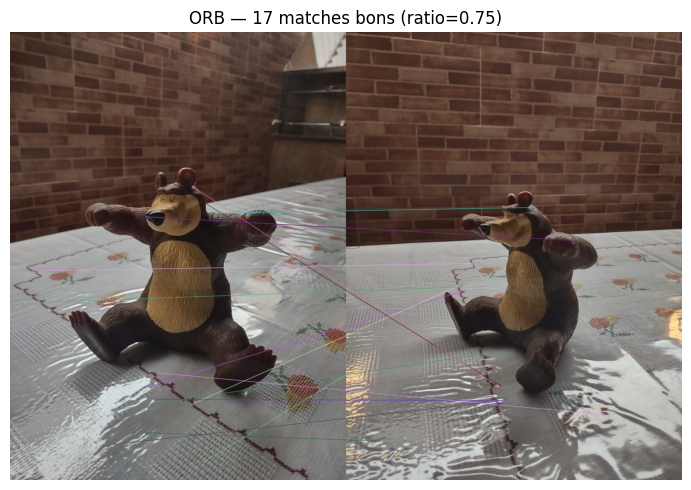

AKAZE: 1636 kp | 36/1636 bons (2.2%)


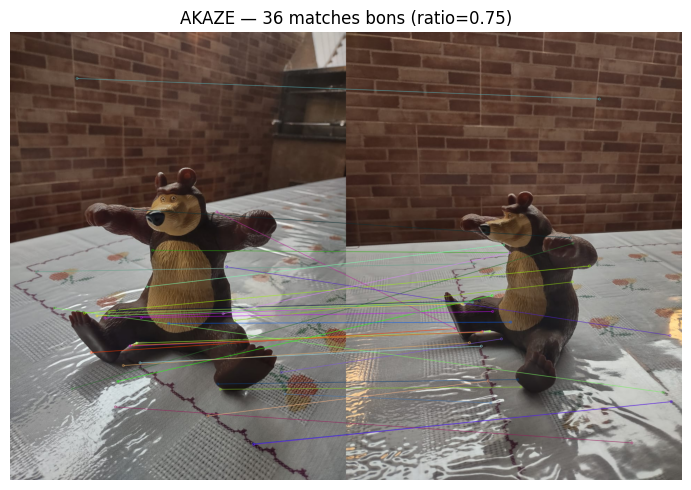

In [4]:
resultados = {}

for det in ['SIFT', 'ORB', 'AKAZE']:
    kp1, kp2, good = pipeline_match(img1, img2, det_name=det, ratio=0.75)
    resultados[det] = {'kp1': kp1, 'kp2': kp2, 'good': good}
    img_m = cv2.drawMatches(img1, kp1, img2, kp2, good, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(14, 5))
    plt.imshow(cv2.cvtColor(img_m, cv2.COLOR_BGR2RGB))
    plt.title(f'{det} — {len(good)} matches bons (ratio=0.75)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

**Observações:**
- O SIFT gera descritores de 128 floats por keypoint, tendendo a detectar mais keypoints e produzir matches de alta precisão graças à distância euclidiana contínua.
- ORB e AKAZE usam representações binárias (~256 e ~488 bits respectivamente); a distância de Hamming é calculada com operações bit-a-bit, tornando o matching muito mais rápido.
- Visualmente, matches ruins formam linhas cruzadas e caóticas; o Ratio Test já eliminou a maioria deles.

## Item 3 — Efeito do Ratio Test (SIFT)

Variamos o limiar do Ratio Test de Lowe entre 0.50 e 0.90 usando apenas o SIFT. Observamos como a quantidade de matches aceitos cresce com o limiar — ao custo de aceitar matches mais ambíguos (ruído visual).

SIFT: 5535 kp | 5/5535 bons (0.1%)


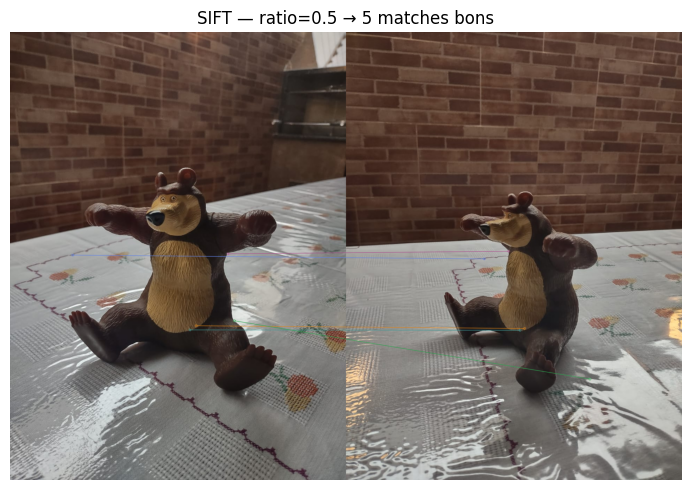

SIFT: 5535 kp | 35/5535 bons (0.6%)


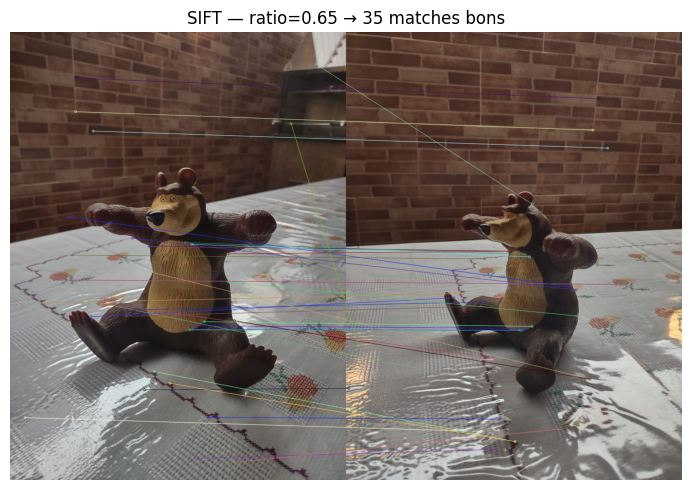

SIFT: 5535 kp | 97/5535 bons (1.8%)


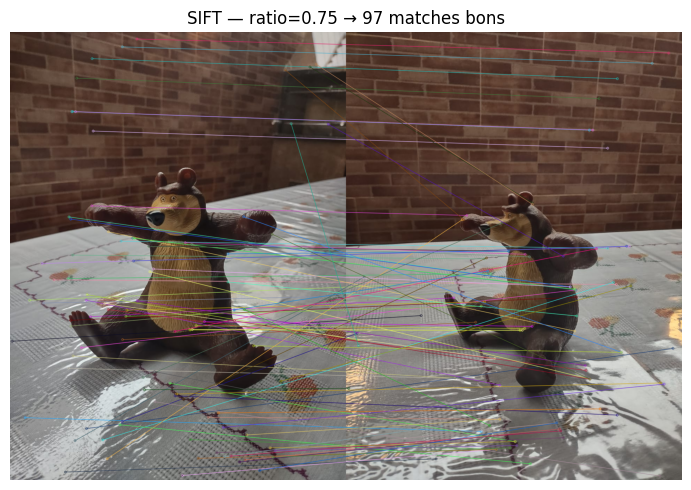

SIFT: 5535 kp | 993/5535 bons (17.9%)


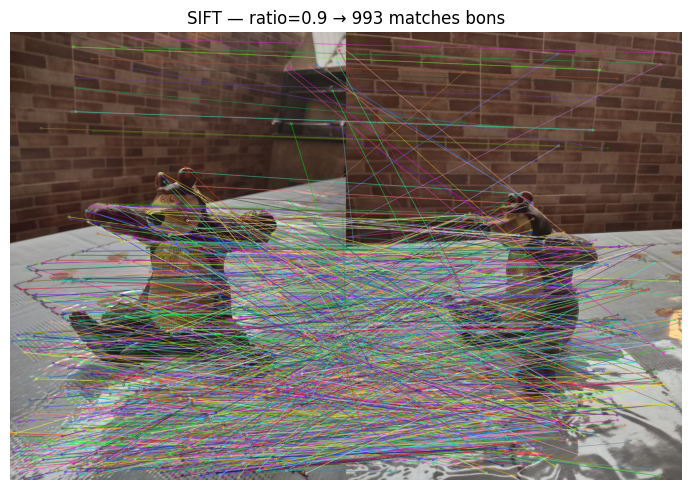

In [5]:
ratios = [0.50, 0.65, 0.75, 0.90]

for r in ratios:
    kp1, kp2, good = pipeline_match(img1, img2, det_name='SIFT', ratio=r)
    img_m = cv2.drawMatches(img1, kp1, img2, kp2, good, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(14, 5))
    plt.imshow(cv2.cvtColor(img_m, cv2.COLOR_BGR2RGB))
    plt.title(f'SIFT — ratio={r} → {len(good)} matches bons')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

**Trade-off quantidade × qualidade:**
- **ratio=0.50**: poucos matches, mas quase todos corretos — linhas paralelas e ordenadas.
- **ratio=0.65**: número moderado; qualidade ainda alta.
- **ratio=0.75** (padrão Lowe): equilíbrio empírico; ~90% dos falsos eliminados, ~90% dos verdadeiros preservados.
- **ratio=0.90**: muitos matches aceitos, porém linhas cruzadas indicam correspondências incorretas (falsos positivos).

Aumentar o limiar torna o matcher mais permissivo; diminuir, mais rigoroso. Para aplicações que exigem precisão (ex.: estimativa de homografia com poucos inliers), use 0.65–0.70. Para aumentar cobertura em cenas difíceis, suba para 0.80–0.85.

In [6]:
print('Tabela comparativa (ratio=0.75):')
print(f'{"Método":<8} {"Distância":<18} {"KPs (img1)":>10} {"Match (%)":>10}')
print('-' * 52)
for det in ['SIFT', 'ORB', 'AKAZE']:
    r = resultados[det]
    kps   = len(r['kp1'])
    n_ok  = len(r['good'])
    norm  = cv2.NORM_L2 if det == 'SIFT' else cv2.NORM_HAMMING
    det_obj = (cv2.SIFT_create() if det == 'SIFT'
               else cv2.ORB_create(nfeatures=2000) if det == 'ORB'
               else cv2.AKAZE_create())
    g1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    _, d1 = det_obj.detectAndCompute(g1, None)
    _, d2 = det_obj.detectAndCompute(g2, None)
    bf = cv2.BFMatcher(norm)
    n_tot = len(bf.knnMatch(d1, d2, k=2))
    pct   = 100 * n_ok / n_tot if n_tot > 0 else 0
    dist  = 'L2 (float)' if det == 'SIFT' else 'Hamming (bin.)'
    print(f'{det:<8} {dist:<18} {kps:>10} {pct:>9.1f}%')

Tabela comparativa (ratio=0.75):
Método   Distância          KPs (img1)  Match (%)
----------------------------------------------------


SIFT     L2 (float)               5535       1.8%
ORB      Hamming (bin.)           2000       0.8%


AKAZE    Hamming (bin.)           1636       2.2%


## Item 4 — Tabela comparativa e análise crítica

| Método | Distância      | KPs (img1) | Match (%) |
|--------|---------------|-----------|-----------|
| SIFT   | L2 (float)    | 5535 | 1.8% |
| ORB    | Hamming (bin.)| 2000 | 0.8% |
| AKAZE  | Hamming (bin.)| 1636 | 2.2% |

*Match (%) = matches bons ÷ total de pares candidatos (ratio=0.75)*

**Análise:**
- **Float vs. binário na prática:** O SIFT produz descritores contínuos de 128 floats (512 bytes/keypoint); a distância euclidiana mede diferenças gradativas. ORB e AKAZE produzem vetores binários (32 e 61 bytes respectivamente); a distância de Hamming conta apenas bits diferentes com uma XOR — ordens de magnitude mais rápida.
- **Quantidade de keypoints:** O ORB detecta exatamente `nfeatures=2000` pontos (limitado por parâmetro); o SIFT não tem limite padrão e detecta conforme a estrutura da imagem; o AKAZE é o mais seletivo.
- **Match (%):** Um percentual alto indica que os descritores discriminam bem — poucas ambiguidades. Um percentual baixo pode indicar descritores menos discriminativos *ou* cena com pouca sobreposição.
- **Quando usar cada um:** SIFT é preferido quando precisão é crítica (ex.: Structure from Motion, AR). ORB/AKAZE são preferidos em sistemas embarcados ou em tempo real (câmera de robô, drone) onde CPU e memória são limitados.

## Conclusão da Tarefa 2

- Implementamos o pipeline completo de matching para 3 descritores clássicos, confirmando que a escolha da métrica de distância deve ser compatível com o tipo do descritor (L2 para float, Hamming para binário).
- O Ratio Test de Lowe mostrou-se essencial: sem ele matches ambíguos dominam a visualização; com `ratio=0.75` obtemos correspondências visualmente coerentes.
- A comparação SIFT × ORB × AKAZE revela o trade-off fundamental: precisão (SIFT, float, mais lento) vs. velocidade (ORB/AKAZE, binário, mais rápido) — a escolha depende dos requisitos de latência e hardware do sistema.